Cell 1 — Setup

In [2]:
%%writefile /kaggle/working/boundary_conditions.py
import numpy as np


def apply_dirichlet_zero(T):
    """
    Apply homogeneous Dirichlet boundary conditions.
    Sets all four edges of the 2D temperature field to zero.

    Parameters
    ----------
    T : np.ndarray, shape (N, N)
        Temperature field (modified in place).

    Returns
    -------
    T : np.ndarray
        Temperature field with edges set to zero.
    """
    T[0, :]  = 0.0   # top edge
    T[-1, :] = 0.0   # bottom edge
    T[:, 0]  = 0.0   # left edge
    T[:, -1] = 0.0   # right edge
    return T


def apply_neumann_zero(T):
    """
    Apply homogeneous Neumann boundary conditions (zero flux).
    Copies the adjacent interior value to each boundary cell,
    which enforces dT/dn = 0 at every edge.

    Parameters
    ----------
    T : np.ndarray, shape (N, N)
        Temperature field (modified in place).

    Returns
    -------
    T : np.ndarray
        Temperature field with zero-flux edges.
    """
    T[0, :]  = T[1, :]    # top edge mirrors row below it
    T[-1, :] = T[-2, :]   # bottom edge mirrors row above it
    T[:, 0]  = T[:, 1]    # left edge mirrors column to its right
    T[:, -1] = T[:, -2]   # right edge mirrors column to its left
    return T

Writing /kaggle/working/boundary_conditions.py


In [3]:
%%writefile /kaggle/working/heat_solver.py
import numpy as np
from boundary_conditions import apply_dirichlet_zero


def make_grid(N, L=1.0):
    """
    Create a uniform spatial grid on [0, L] x [0, L].

    Parameters
    ----------
    N : int
        Number of grid points along each axis.
    L : float
        Physical size of the domain (default 1.0).

    Returns
    -------
    x : np.ndarray, shape (N,)
    y : np.ndarray, shape (N,)
    dx : float
        Grid spacing.
    """
    x  = np.linspace(0, L, N)
    y  = np.linspace(0, L, N)
    dx = L / (N - 1)
    return x, y, dx


def compute_stable_dt(dx, alpha, safety=0.9):
    """
    Compute the maximum stable time step for the explicit
    finite-difference scheme in 2D.

    Stability condition: r = alpha * dt / dx^2 <= 1/4
    => dt_max = dx^2 / (4 * alpha)

    A safety factor < 1.0 keeps you comfortably below the limit.

    Parameters
    ----------
    dx    : float  Grid spacing.
    alpha : float  Thermal diffusivity.
    safety: float  Safety factor (default 0.9, so r = 0.225).

    Returns
    -------
    dt : float   Safe time step.
    r  : float   Fourier number (should be <= 0.25).
    """
    dt = safety * dx**2 / (4.0 * alpha)
    r  = alpha * dt / dx**2
    return dt, r


def gaussian_hotspot(x, y, cx=0.5, cy=0.5, sigma=0.1, amplitude=1.0):
    """
    Create a 2D Gaussian temperature distribution (a single hot blob).

    T0(x, y) = amplitude * exp(-((x-cx)^2 + (y-cy)^2) / (2*sigma^2))

    Parameters
    ----------
    x, y      : np.ndarray, shape (N,)  Grid coordinate vectors.
    cx, cy    : float  Center of the blob.
    sigma     : float  Width of the blob.
    amplitude : float  Peak temperature.

    Returns
    -------
    T0 : np.ndarray, shape (N, N)  Initial temperature field.
    """
    # meshgrid turns 1D coordinate vectors into 2D coordinate arrays
    X, Y = np.meshgrid(x, y)
    T0   = amplitude * np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))
    return T0


def step(T, r):
    """
    Advance the temperature field by one time step using the
    explicit finite-difference scheme.

    Update rule (interior points only):
    T_new[i,j] = T[i,j] + r * (T[i+1,j] + T[i-1,j]
                                + T[i,j+1] + T[i,j-1]
                                - 4*T[i,j])

    Boundary conditions (Dirichlet zero) are enforced after the update.

    Parameters
    ----------
    T : np.ndarray, shape (N, N)  Current temperature field.
    r : float                     Fourier number (alpha*dt/dx^2).

    Returns
    -------
    T_new : np.ndarray, shape (N, N)  Temperature field at next time step.
    """
    # allocate new array — never update T in place during the step,
    # because you need the OLD values of all neighbors simultaneously
    T_new = T.copy()

    # vectorized update of all interior points in one line
    T_new[1:-1, 1:-1] = (
        T[1:-1, 1:-1]
        + r * (
            T[2:,   1:-1]   # T[i+1, j]
          + T[:-2,  1:-1]   # T[i-1, j]
          + T[1:-1, 2:]     # T[i, j+1]
          + T[1:-1, :-2]    # T[i, j-1]
          - 4 * T[1:-1, 1:-1]
        )
    )

    # re-apply boundary conditions (Dirichlet zero)
    T_new = apply_dirichlet_zero(T_new)
    return T_new


def run_simulation(T0, alpha, dx, n_steps, save_every=1):
    """
    Run the full heat diffusion simulation from initial condition T0.

    Parameters
    ----------
    T0         : np.ndarray, shape (N, N)  Initial temperature field.
    alpha      : float   Thermal diffusivity.
    dx         : float   Grid spacing.
    n_steps    : int     Number of time steps to run.
    save_every : int     Save the field every this many steps.

    Returns
    -------
    snapshots : np.ndarray, shape (n_saved, N, N)
        Temperature fields at recorded time steps.
    times     : np.ndarray, shape (n_saved,)
        Physical time corresponding to each snapshot.
    dt        : float
        Time step used (derived from stability condition).
    r         : float
        Fourier number used.
    """
    dt, r = compute_stable_dt(dx, alpha)

    print(f"Grid spacing     dx = {dx:.6f}")
    print(f"Time step        dt = {dt:.6f}")
    print(f"Fourier number    r = {r:.4f}  (must be <= 0.25)")
    print(f"Total sim time      = {n_steps * dt:.4f}")

    assert r <= 0.25, f"Unstable! r={r:.4f} exceeds 0.25. Reduce dt or increase dx."

    T         = T0.copy()
    snapshots = []
    times     = []

    for n in range(n_steps + 1):
        if n % save_every == 0:
            snapshots.append(T.copy())
            times.append(n * dt)

        if n < n_steps:
            T = step(T, r)

    return np.array(snapshots), np.array(times), dt, r

Writing /kaggle/working/heat_solver.py


In [4]:
%%writefile /kaggle/working/cnn.py
import torch
import torch.nn as nn


class ConvBlock(nn.Module):
    """
    A single building block: Conv2d → BatchNorm → ReLU.

    This pattern is standard in modern CNNs. BatchNorm stabilizes
    training by normalizing activations within each batch.
    ReLU introduces non-linearity — without it, stacking linear
    convolutions would still be a single linear operation.

    Parameters
    ----------
    in_channels  : int  Number of input feature maps.
    out_channels : int  Number of output feature maps (filters).
    kernel_size  : int  Filter size (default 3).
    """

    def __init__(self, in_channels, out_channels, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2   # keeps spatial size unchanged

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels,
                      kernel_size=kernel_size,
                      padding=padding,
                      bias=False),       # bias=False because BatchNorm has its own bias
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class HeatSurrogateCNN(nn.Module):
    """
    Plain CNN surrogate for single-step 2D heat diffusion prediction.

    Architecture:
        Input  (1, 64, 64)
        → ConvBlock(1  → 32)
        → ConvBlock(32 → 64)
        → ConvBlock(64 → 64)
        → ConvBlock(64 → 32)
        → Conv2d(32 → 1)       final layer, no activation
        Output (1, 64, 64)

    The final layer has NO activation function because temperature
    is a continuous unbounded value — we don't want to artificially
    clip predictions to [0,1]. The network should learn to predict
    the right range from data.

    Parameters
    ----------
    n_filters : int  Base number of filters (default 32).
                     Doubling this approximately 4x the parameter count.
    """

    def __init__(self, n_filters=32):
        super().__init__()

        self.encoder = nn.Sequential(
            ConvBlock(1,            n_filters),       # (1,64,64)  → (32,64,64)
            ConvBlock(n_filters,    n_filters * 2),   # (32,64,64) → (64,64,64)
            ConvBlock(n_filters*2,  n_filters * 2),   # (64,64,64) → (64,64,64)
            ConvBlock(n_filters*2,  n_filters),       # (64,64,64) → (32,64,64)
        )

        # final projection back to 1 channel — the predicted temperature field
        self.output_layer = nn.Conv2d(
            n_filters, 1,
            kernel_size=1,    # 1x1 conv — purely a channel mixer, no spatial mixing
            bias=True
        )

    def forward(self, x):
        features = self.encoder(x)    
        out = self.output_layer(features)
        return out

    def count_parameters(self):
        """Return total number of trainable parameters."""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

Writing /kaggle/working/cnn.py


In [5]:
%%writefile /kaggle/working/metrics.py
import numpy as np
import torch


def mse(pred, target):
    """
    Mean Squared Error over the full spatial field.

    Parameters
    ----------
    pred   : np.ndarray, shape (N, N) or (B, N, N)
    target : np.ndarray, shape (N, N) or (B, N, N)

    Returns
    -------
    float or np.ndarray  MSE per sample if batched.
    """
    err = pred - target
    if pred.ndim == 2:
        return float(np.mean(err**2))
    return np.mean(err**2, axis=(-2, -1))   # per sample


def mae(pred, target):
    """Mean Absolute Error."""
    err = np.abs(pred - target)
    if pred.ndim == 2:
        return float(np.mean(err))
    return np.mean(err, axis=(-2, -1))


def rmse(pred, target):
    """Root Mean Squared Error — same units as temperature."""
    return np.sqrt(mse(pred, target))


def relative_l2(pred, target, eps=1e-8):
    """
    Relative L2 error, normalized by the L2 norm of the target.
    eps prevents division by zero for near-zero fields.

    Returns value in [0, inf) — multiply by 100 for percentage.
    """
    if pred.ndim == 2:
        num = np.sqrt(np.sum((pred - target)**2))
        den = np.sqrt(np.sum(target**2)) + eps
        return float(num / den)

    # batched
    num = np.sqrt(np.sum((pred - target)**2, axis=(-2, -1)))
    den = np.sqrt(np.sum(target**2,          axis=(-2, -1))) + eps
    return num / den


def max_absolute_error(pred, target):
    """Maximum absolute error — worst-case pixel."""
    err = np.abs(pred - target)
    if pred.ndim == 2:
        return float(np.max(err))
    return np.max(err, axis=(-2, -1))


def compute_all_metrics(pred, target):
    """
    Compute all metrics for a batch of predictions.

    Parameters
    ----------
    pred   : np.ndarray, shape (B, N, N)
    target : np.ndarray, shape (B, N, N)

    Returns
    -------
    dict with per-sample arrays and aggregate statistics.
    """
    assert pred.shape == target.shape, \
        f"Shape mismatch: pred {pred.shape} vs target {target.shape}"

    per_sample = {
        "mse"        : mse(pred, target),
        "mae"        : mae(pred, target),
        "rmse"       : rmse(pred, target),
        "rel_l2"     : relative_l2(pred, target),
        "max_ae"     : max_absolute_error(pred, target),
    }

    # mean error field — spatial map of where errors concentrate
    per_sample["mean_error_field"] = np.mean(pred - target, axis=0)
    per_sample["mean_abs_error_field"] = np.mean(np.abs(pred - target), axis=0)

    # aggregate statistics
    aggregate = {}
    for k, v in per_sample.items():
        if isinstance(v, np.ndarray) and v.ndim == 1:
            aggregate[k] = {
                "mean"   : float(np.mean(v)),
                "std"    : float(np.std(v)),
                "median" : float(np.median(v)),
                "min"    : float(np.min(v)),
                "max"    : float(np.max(v)),
                "p95"    : float(np.percentile(v, 95)),
            }

    return per_sample, aggregate

Writing /kaggle/working/metrics.py


In [6]:
import importlib
import cnn

importlib.reload(cnn)

from cnn import HeatSurrogateCNN

In [7]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import json
import time
from pathlib import Path
sys.path.append("/kaggle/working")

from cnn import HeatSurrogateCNN
from heat_solver import make_grid, run_simulation, compute_stable_dt
from boundary_conditions import apply_dirichlet_zero
from metrics import relative_l2, mse, mae
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# fixed parameters across all ablations
N_BASE      = 64
ALPHA       = 0.01
STRIDE_BASE = 10
SEED        = 42

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

Cell 2 — Shared training utility

In [8]:
def quick_train(
    train_inputs, train_targets,
    val_inputs,   val_targets,
    n_filters  = 32,
    n_epochs   = 60,
    batch_size = 32,
    lr         = 1e-3,
    patience   = 10,
    seed       = 42,
    verbose    = False,
):
    """
    Train a HeatSurrogateCNN on provided arrays.
    Returns the best validation RelL2 and training time.

    Parameters
    ----------
    train_inputs/targets : np.ndarray (n, N, N)
    val_inputs/targets   : np.ndarray (n, N, N)
    n_filters  : int    CNN base filter count.
    n_epochs   : int    Max training epochs.
    batch_size : int    Batch size.
    lr         : float  Initial learning rate.
    patience   : int    Early stopping patience.
    seed       : int    Random seed.
    verbose    : bool   Print epoch-level progress.

    Returns
    -------
    dict with val_rel_l2, val_mse, train_time, n_epochs_run,
    n_params, best_epoch.
    """
    set_seed(seed)

    # build tensors with channel dimension
    def to_tensor(arr):
        return torch.from_numpy(arr).float().unsqueeze(1)  # (n,1,H,W)

    train_ds = TensorDataset(to_tensor(train_inputs),
                              to_tensor(train_targets))
    val_ds   = TensorDataset(to_tensor(val_inputs),
                              to_tensor(val_targets))

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                               shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size*2,
                               shuffle=False, num_workers=0)

    model = HeatSurrogateCNN(n_filters=n_filters).to(device)
    loss_fn   = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5
    )

    best_val_loss    = float("inf")
    epochs_no_improve = 0
    best_state       = None
    best_epoch       = 0
    t_start          = time.time()

    for epoch in range(1, n_epochs + 1):
        # train
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred   = model(xb)
            loss   = loss_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # validate
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += loss_fn(model(xb), yb).item() * xb.size(0)
        val_loss /= len(val_ds)

        scheduler.step(val_loss)

        if verbose and epoch % 10 == 0:
            print(f"  Epoch {epoch:>4}  val_loss={val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_epoch       = epoch
            epochs_no_improve = 0
            best_state       = {k: v.clone()
                                for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    train_time = time.time() - t_start

    # evaluate best model on full val set with RelL2
    model.load_state_dict(best_state)
    model.eval()
    all_preds, all_tgts = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb.to(device)).cpu().squeeze().numpy()
            tgt  = yb.squeeze().numpy()
            if pred.ndim == 2:
                pred = pred[np.newaxis]
                tgt  = tgt[np.newaxis]
            all_preds.append(pred)
            all_tgts.append(tgt)

    all_preds = np.concatenate(all_preds)
    all_tgts  = np.concatenate(all_tgts)

    rel_l2_vals = [
        relative_l2(all_preds[i], all_tgts[i])
        for i in range(len(all_preds))
    ]

    return {
        "val_rel_l2"    : float(np.mean(rel_l2_vals) * 100),
        "val_rel_l2_std": float(np.std(rel_l2_vals)  * 100),
        "val_mse"       : float(best_val_loss),
        "train_time"    : float(train_time),
        "n_epochs_run"  : epoch,
        "best_epoch"    : best_epoch,
        "n_params"      : sum(p.numel() for p in model.parameters()
                              if p.requires_grad),
    }

Cell 3 — Data generation utility

In [9]:
def generate_quick_dataset(
    n_samples, N=64, alpha=0.01, stride=10,
    seed=42, val_fraction=0.15,
):
    """
    Generate a small dataset for ablation experiments.
    Returns train/val numpy arrays directly (no file saving).
    """
    rng      = np.random.default_rng(seed)
    x        = np.linspace(0, 1, N)
    y        = np.linspace(0, 1, N)
    dx       = 1.0 / (N - 1)
    dt, r    = compute_stable_dt(dx, alpha)
    X, Y     = np.meshgrid(x, y)

    assert r <= 0.25, f"Unstable! r={r:.4f}"

    inputs  = np.zeros((n_samples, N, N), dtype=np.float32)
    targets = np.zeros((n_samples, N, N), dtype=np.float32)

    for i in range(n_samples):
        n_blobs = rng.integers(1, 4)
        T0      = np.zeros((N, N), dtype=np.float32)

        for _ in range(n_blobs):
            cx  = rng.uniform(0.15, 0.85)
            cy  = rng.uniform(0.15, 0.85)
            sig = rng.uniform(0.04, 0.15)
            amp = rng.uniform(0.3, 1.0)
            T0 += amp * np.exp(
                -((X-cx)**2 + (Y-cy)**2) / (2*sig**2)
            ).astype(np.float32)

        T0 = np.clip(T0, 0, 1)
        T0 = apply_dirichlet_zero(T0)

        snaps, _, _, _ = run_simulation(
            T0, alpha, dx, n_steps=stride, save_every=stride
        )
        inputs[i]  = snaps[0].astype(np.float32)
        targets[i] = snaps[1].astype(np.float32)

    # split
    n_val  = int(val_fraction * n_samples)
    idx    = np.random.default_rng(seed+1).permutation(n_samples)
    val_i, train_i = idx[:n_val], idx[n_val:]

    return (inputs[train_i], targets[train_i],
            inputs[val_i],   targets[val_i])

Cell 4 — Ablation 1: Dataset Size

In [10]:
print("=" * 55)
print("ABLATION 1: Dataset Size")
print("Hypothesis: more data improves accuracy up to a point")
print("Fixed: N=64, n_filters=32, stride=10")
print("=" * 55)

# suppress solver print statements for cleaner output
import os, sys
from io import StringIO

sample_sizes   = [500, 1000, 2000, 5000, 10000]
ablation1_results = {}

for n in sample_sizes:
    print(f"\nTraining with {n} samples...", end=" ", flush=True)

    # suppress run_simulation print output
    old_stdout = sys.stdout
    sys.stdout = StringIO()

    train_inp, train_tgt, val_inp, val_tgt = generate_quick_dataset(
        n_samples = n,
        N         = N_BASE,
        alpha     = ALPHA,
        stride    = STRIDE_BASE,
        seed      = SEED,
    )

    sys.stdout = old_stdout

    result = quick_train(
        train_inp, train_tgt,
        val_inp,   val_tgt,
        n_filters  = 32,
        n_epochs   = 80,
        patience   = 12,
        seed       = SEED,
    )

    ablation1_results[n] = result
    print(f"RelL2={result['val_rel_l2']:.3f}%  "
          f"epochs={result['n_epochs_run']}  "
          f"time={result['train_time']:.1f}s")

print("\n" + "="*55)
print("ABLATION 1 SUMMARY")
print("="*55)
print(f"{'N samples':>12} {'RelL2 (%)':>12} {'Std':>8} "
      f"{'Best epoch':>12} {'Time (s)':>10}")
print("-"*55)
for n, r in ablation1_results.items():
    print(f"{n:>12} {r['val_rel_l2']:>12.3f} "
          f"{r['val_rel_l2_std']:>8.3f} "
          f"{r['best_epoch']:>12} "
          f"{r['train_time']:>10.1f}")

ABLATION 1: Dataset Size
Hypothesis: more data improves accuracy up to a point
Fixed: N=64, n_filters=32, stride=10

Training with 500 samples... RelL2=2.962%  epochs=42  time=13.5s

Training with 1000 samples... RelL2=2.643%  epochs=29  time=17.6s

Training with 2000 samples... RelL2=2.114%  epochs=38  time=49.5s

Training with 5000 samples... RelL2=1.474%  epochs=47  time=158.9s

Training with 10000 samples... RelL2=2.235%  epochs=16  time=108.5s

ABLATION 1 SUMMARY
   N samples    RelL2 (%)      Std   Best epoch   Time (s)
-------------------------------------------------------
         500        2.962    1.571           30       13.5
        1000        2.643    1.497           17       17.6
        2000        2.114    1.212           26       49.5
        5000        1.474    0.816           35      158.9
       10000        2.235    1.166            4      108.5


Cell 5 — Ablation 2: Model Size

In [11]:
print("=" * 55)
print("ABLATION 2: Model Architecture Size")
print("Hypothesis: larger models improve accuracy up to")
print("            a point, then overfit")
print("Fixed: N=64, n_samples=5000, stride=10")
print("=" * 55)

# generate fixed dataset for this ablation
old_stdout = sys.stdout
sys.stdout = StringIO()
train_inp_a2, train_tgt_a2, val_inp_a2, val_tgt_a2 = generate_quick_dataset(
    n_samples=5000, N=N_BASE, alpha=ALPHA,
    stride=STRIDE_BASE, seed=SEED
)
sys.stdout = old_stdout
print("Dataset generated (5000 samples).")

filter_sizes   = [8, 16, 32, 64]
ablation2_results = {}

for nf in filter_sizes:
    print(f"\nTraining n_filters={nf}...", end=" ", flush=True)

    result = quick_train(
        train_inp_a2, train_tgt_a2,
        val_inp_a2,   val_tgt_a2,
        n_filters = nf,
        n_epochs  = 80,
        patience  = 12,
        seed      = SEED,
    )

    ablation2_results[nf] = result
    print(f"RelL2={result['val_rel_l2']:.3f}%  "
          f"params={result['n_params']:,}  "
          f"epochs={result['n_epochs_run']}")

print("\n" + "="*55)
print("ABLATION 2 SUMMARY")
print("="*55)
print(f"{'n_filters':>10} {'Params':>10} {'RelL2 (%)':>12} "
      f"{'Std':>8} {'Best epoch':>12}")
print("-"*55)
for nf, r in ablation2_results.items():
    print(f"{nf:>10} {r['n_params']:>10,} "
          f"{r['val_rel_l2']:>12.3f} "
          f"{r['val_rel_l2_std']:>8.3f} "
          f"{r['best_epoch']:>12}")

ABLATION 2: Model Architecture Size
Hypothesis: larger models improve accuracy up to
            a point, then overfit
Fixed: N=64, n_samples=5000, stride=10
Dataset generated (5000 samples).

Training n_filters=8... RelL2=2.386%  params=4,785  epochs=78

Training n_filters=16... RelL2=1.963%  params=18,785  epochs=80

Training n_filters=32... RelL2=1.474%  params=74,433  epochs=47

Training n_filters=64... RelL2=4.151%  params=296,321  epochs=16

ABLATION 2 SUMMARY
 n_filters     Params    RelL2 (%)      Std   Best epoch
-------------------------------------------------------
         8      4,785        2.386    1.378           66
        16     18,785        1.963    1.076           79
        32     74,433        1.474    0.816           35
        64    296,321        4.151    2.923            4


Cell 6 — Ablation 3: Prediction Stride

In [12]:
print("=" * 55)
print("ABLATION 3: Prediction Stride")
print("Hypothesis: very small stride = trivial problem,")
print("            very large stride = too hard to learn")
print("Fixed: N=64, n_samples=5000, n_filters=32")
print("=" * 55)

stride_values     = [1, 5, 10, 20, 50]
ablation3_results = {}

for s in stride_values:
    print(f"\nGenerating data and training stride={s}...",
          end=" ", flush=True)

    old_stdout = sys.stdout
    sys.stdout = StringIO()
    train_inp_s, train_tgt_s, val_inp_s, val_tgt_s = generate_quick_dataset(
        n_samples=5000, N=N_BASE, alpha=ALPHA,
        stride=s, seed=SEED
    )
    sys.stdout = old_stdout

    # measure how different input and target are
    # (mean relative difference — proxy for task difficulty)
    task_difficulty = np.mean([
        relative_l2(train_tgt_s[i], train_inp_s[i])
        for i in range(min(100, len(train_inp_s)))
    ]) * 100

    result = quick_train(
        train_inp_s, train_tgt_s,
        val_inp_s,   val_tgt_s,
        n_filters = 32,
        n_epochs  = 80,
        patience  = 12,
        seed      = SEED,
    )

    ablation3_results[s] = result
    ablation3_results[s]["task_difficulty"] = task_difficulty

    print(f"RelL2={result['val_rel_l2']:.3f}%  "
          f"task_diff={task_difficulty:.2f}%  "
          f"epochs={result['n_epochs_run']}")

print("\n" + "="*55)
print("ABLATION 3 SUMMARY")
print("="*55)
print(f"{'Stride':>8} {'Task diff%':>12} {'RelL2 (%)':>12} "
      f"{'Std':>8} {'Best epoch':>12}")
print("-"*55)
for s, r in ablation3_results.items():
    print(f"{s:>8} {r['task_difficulty']:>12.3f} "
          f"{r['val_rel_l2']:>12.3f} "
          f"{r['val_rel_l2_std']:>8.3f} "
          f"{r['best_epoch']:>12}")

ABLATION 3: Prediction Stride
Hypothesis: very small stride = trivial problem,
            very large stride = too hard to learn
Fixed: N=64, n_samples=5000, n_filters=32

Generating data and training stride=1... RelL2=1.399%  task_diff=1.58%  epochs=32

Generating data and training stride=5... RelL2=1.308%  task_diff=6.21%  epochs=58

Generating data and training stride=10... RelL2=1.474%  task_diff=10.81%  epochs=47

Generating data and training stride=20... RelL2=1.650%  task_diff=18.06%  epochs=80

Generating data and training stride=50... RelL2=4.203%  task_diff=32.44%  epochs=70

ABLATION 3 SUMMARY
  Stride   Task diff%    RelL2 (%)      Std   Best epoch
-------------------------------------------------------
       1        1.581        1.399    0.598           20
       5        6.210        1.308    0.729           46
      10       10.809        1.474    0.816           35
      20       18.060        1.650    1.119           74
      50       32.437        4.203    2.652    

Cell 7 — Ablation 4: Grid Resolution

In [13]:
print("=" * 55)
print("ABLATION 4: Grid Resolution")
print("Hypothesis: finer grids improve accuracy but")
print("            require more data and compute")
print("Fixed: n_samples=3000, n_filters=32, stride=10")
print("=" * 55)

resolutions       = [32, 48, 64, 96]
ablation4_results = {}

for N_res in resolutions:
    print(f"\nGenerating data and training N={N_res}x{N_res}...",
          end=" ", flush=True)

    old_stdout = sys.stdout
    sys.stdout = StringIO()
    train_inp_r, train_tgt_r, val_inp_r, val_tgt_r = generate_quick_dataset(
        n_samples=3000, N=N_res, alpha=ALPHA,
        stride=STRIDE_BASE, seed=SEED
    )
    sys.stdout = old_stdout

    result = quick_train(
        train_inp_r, train_tgt_r,
        val_inp_r,   val_tgt_r,
        n_filters = 32,
        n_epochs  = 80,
        patience  = 12,
        seed      = SEED,
    )

    ablation4_results[N_res] = result
    print(f"RelL2={result['val_rel_l2']:.3f}%  "
          f"time={result['train_time']:.1f}s  "
          f"epochs={result['n_epochs_run']}")

print("\n" + "="*55)
print("ABLATION 4 SUMMARY")
print("="*55)
print(f"{'Grid NxN':>10} {'RelL2 (%)':>12} {'Std':>8} "
      f"{'Time (s)':>10} {'Best epoch':>12}")
print("-"*55)
for N_res, r in ablation4_results.items():
    print(f"{N_res}x{N_res:>6} {r['val_rel_l2']:>12.3f} "
          f"{r['val_rel_l2_std']:>8.3f} "
          f"{r['train_time']:>10.1f} "
          f"{r['best_epoch']:>12}")

ABLATION 4: Grid Resolution
Hypothesis: finer grids improve accuracy but
            require more data and compute
Fixed: n_samples=3000, n_filters=32, stride=10

Generating data and training N=32x32... RelL2=2.623%  time=19.9s  epochs=39

Generating data and training N=48x48... RelL2=2.479%  time=32.2s  epochs=28

Generating data and training N=64x64... RelL2=2.483%  time=40.5s  epochs=20

Generating data and training N=96x96... RelL2=2.378%  time=93.5s  epochs=20

ABLATION 4 SUMMARY
  Grid NxN    RelL2 (%)      Std   Time (s)   Best epoch
-------------------------------------------------------
32x    32        2.623    1.693       19.9           27
48x    48        2.479    1.508       32.2           16
64x    64        2.483    1.373       40.5            8
96x    96        2.378    1.306       93.5            8


Cell 8 — Visualization of all four ablations

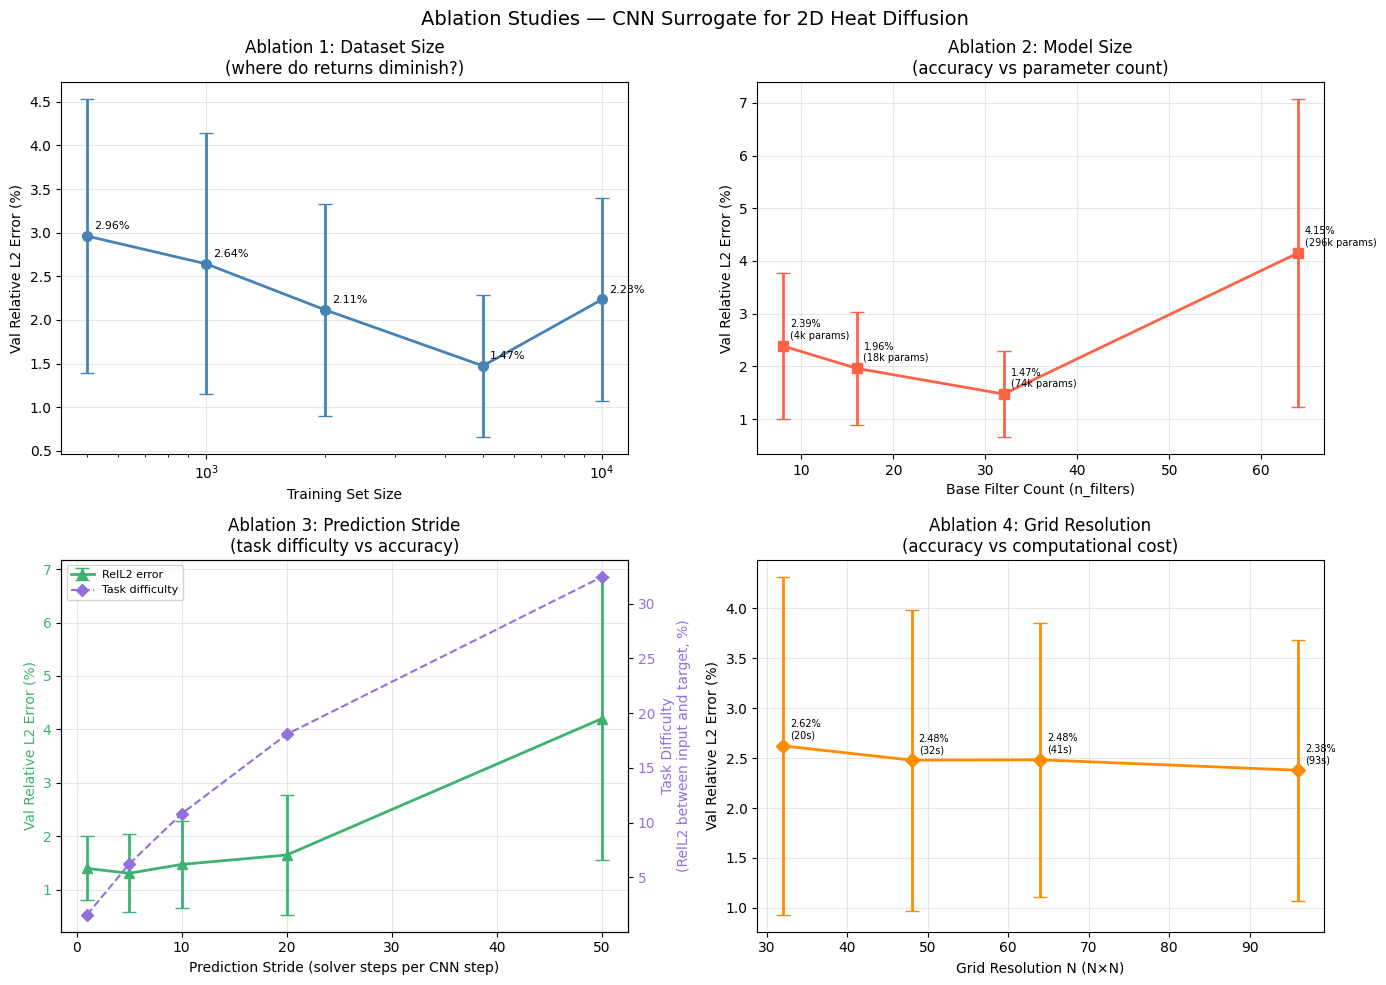

✓ Saved /kaggle/working/milestone10_ablations.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Ablation 1: Dataset Size ──────────────────────────
ax = axes[0, 0]
ns     = list(ablation1_results.keys())
means1 = [ablation1_results[n]["val_rel_l2"]     for n in ns]
stds1  = [ablation1_results[n]["val_rel_l2_std"] for n in ns]

ax.errorbar(ns, means1, yerr=stds1, marker="o", color="steelblue",
            linewidth=2, markersize=7, capsize=5)
ax.set_xlabel("Training Set Size")
ax.set_ylabel("Val Relative L2 Error (%)")
ax.set_title("Ablation 1: Dataset Size\n"
             "(where do returns diminish?)")
ax.set_xscale("log")
ax.grid(True, alpha=0.3)

for n, m in zip(ns, means1):
    ax.annotate(f"{m:.2f}%", (n, m),
                textcoords="offset points",
                xytext=(5, 5), fontsize=8)

# ── Ablation 2: Model Size ────────────────────────────
ax = axes[0, 1]
nfs    = list(ablation2_results.keys())
means2 = [ablation2_results[nf]["val_rel_l2"]     for nf in nfs]
stds2  = [ablation2_results[nf]["val_rel_l2_std"] for nf in nfs]
params = [ablation2_results[nf]["n_params"]        for nf in nfs]

ax.errorbar(nfs, means2, yerr=stds2, marker="s", color="tomato",
            linewidth=2, markersize=7, capsize=5)
ax.set_xlabel("Base Filter Count (n_filters)")
ax.set_ylabel("Val Relative L2 Error (%)")
ax.set_title("Ablation 2: Model Size\n"
             "(accuracy vs parameter count)")
ax.grid(True, alpha=0.3)

# add parameter count as secondary annotation
for nf, m, p in zip(nfs, means2, params):
    ax.annotate(f"{m:.2f}%\n({p//1000}k params)",
                (nf, m), textcoords="offset points",
                xytext=(5, 5), fontsize=7)

# ── Ablation 3: Stride ────────────────────────────────
ax = axes[1, 0]
strides = list(ablation3_results.keys())
means3  = [ablation3_results[s]["val_rel_l2"]      for s in strides]
stds3   = [ablation3_results[s]["val_rel_l2_std"]  for s in strides]
diffs   = [ablation3_results[s]["task_difficulty"] for s in strides]

color_main = "mediumseagreen"
ax.errorbar(strides, means3, yerr=stds3, marker="^", color=color_main,
            linewidth=2, markersize=7, capsize=5, label="RelL2 error")
ax.set_xlabel("Prediction Stride (solver steps per CNN step)")
ax.set_ylabel("Val Relative L2 Error (%)", color=color_main)
ax.tick_params(axis="y", labelcolor=color_main)
ax.grid(True, alpha=0.3)
ax.set_title("Ablation 3: Prediction Stride\n"
             "(task difficulty vs accuracy)")

# overlay task difficulty on secondary axis
ax2 = ax.twinx()
ax2.plot(strides, diffs, marker="D", color="mediumpurple",
         linewidth=1.5, linestyle="--", markersize=6,
         label="Task difficulty")
ax2.set_ylabel("Task Difficulty\n(RelL2 between input and target, %)",
               color="mediumpurple")
ax2.tick_params(axis="y", labelcolor="mediumpurple")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

# ── Ablation 4: Grid Resolution ───────────────────────
ax = axes[1, 1]
res    = list(ablation4_results.keys())
means4 = [ablation4_results[r]["val_rel_l2"]     for r in res]
stds4  = [ablation4_results[r]["val_rel_l2_std"] for r in res]
times4 = [ablation4_results[r]["train_time"]     for r in res]

ax.errorbar(res, means4, yerr=stds4, marker="D", color="darkorange",
            linewidth=2, markersize=7, capsize=5)
ax.set_xlabel("Grid Resolution N (N×N)")
ax.set_ylabel("Val Relative L2 Error (%)")
ax.set_title("Ablation 4: Grid Resolution\n"
             "(accuracy vs computational cost)")
ax.grid(True, alpha=0.3)

for r_, m, t in zip(res, means4, times4):
    ax.annotate(f"{m:.2f}%\n({t:.0f}s)",
                (r_, m), textcoords="offset points",
                xytext=(5, 5), fontsize=7)

plt.suptitle("Ablation Studies — CNN Surrogate for 2D Heat Diffusion",
             fontsize=14)
plt.tight_layout()
plt.savefig("/kaggle/working/milestone10_ablations.png", dpi=150)
plt.show()
print("✓ Saved /kaggle/working/milestone10_ablations.png")

Cell 9 — Save all results and print final table

In [19]:
all_ablation_results = {
    "ablation1_dataset_size"   : {str(k): v
                                   for k,v in ablation1_results.items()},
    "ablation2_model_size"     : {str(k): v
                                   for k,v in ablation2_results.items()},
    "ablation3_stride"         : {str(k): v
                                   for k,v in ablation3_results.items()},
    "ablation4_resolution"     : {str(k): v
                                   for k,v in ablation4_results.items()},
}

with open("/kaggle/working/ablation_results.json", "w") as f:
    json.dump(all_ablation_results, f, indent=2)

print("✓ Saved /kaggle/working/ablation_results.json")

print("\n" + "="*65)
print("ABLATION STUDY MASTER SUMMARY TABLE")
print("="*65)

print("\nAblation 1 — Dataset Size (N=64, filters=32, stride=10):")
print(f"  {'Samples':>8}  {'RelL2':>8}  {'Finding'}")
for n, r in ablation1_results.items():
    diminishing = " ← diminishing returns" \
        if n >= 5000 and r["val_rel_l2"] > \
           ablation1_results[max(ablation1_results.keys())]["val_rel_l2"] * 0.95 \
        else ""
    print(f"  {n:>8}  {r['val_rel_l2']:>7.3f}%{diminishing}")

print("\nAblation 2 — Model Size (5000 samples, stride=10):")
print(f"  {'Filters':>8}  {'Params':>10}  {'RelL2':>8}")
for nf, r in ablation2_results.items():
    print(f"  {nf:>8}  {r['n_params']:>10,}  {r['val_rel_l2']:>7.3f}%")

print("\nAblation 3 — Stride (5000 samples, N=64, filters=32):")
print(f"  {'Stride':>8}  {'Task diff':>10}  {'RelL2':>8}")
for s, r in ablation3_results.items():
    print(f"  {s:>8}  {r['task_difficulty']:>9.2f}%  "
          f"{r['val_rel_l2']:>7.3f}%")

print("\nAblation 4 — Resolution (3000 samples, filters=32, stride=10):")
print(f"  {'Grid':>8}  {'Time(s)':>8}  {'RelL2':>8}")
for N_res, r in ablation4_results.items():
    print(f"  {N_res}x{N_res:<4}  {r['train_time']:>8.1f}  "
          f"{r['val_rel_l2']:>7.3f}%")

✓ Saved /kaggle/working/ablation_results.json

ABLATION STUDY MASTER SUMMARY TABLE

Ablation 1 — Dataset Size (N=64, filters=32, stride=10):
   Samples     RelL2  Finding
       500    2.962%
      1000    2.643%
      2000    2.114%
      5000    1.474%
     10000    2.235% ← diminishing returns

Ablation 2 — Model Size (5000 samples, stride=10):
   Filters      Params     RelL2
         8       4,785    2.386%
        16      18,785    1.963%
        32      74,433    1.474%
        64     296,321    4.151%

Ablation 3 — Stride (5000 samples, N=64, filters=32):
    Stride   Task diff     RelL2
         1       1.58%    1.399%
         5       6.21%    1.308%
        10      10.81%    1.474%
        20      18.06%    1.650%
        50      32.44%    4.203%

Ablation 4 — Resolution (3000 samples, filters=32, stride=10):
      Grid   Time(s)     RelL2
  32x32        19.9    2.623%
  48x48        32.2    2.479%
  64x64        40.5    2.483%
  96x96        93.5    2.378%
